# **Benchmark -** Plots

___
___

### **1. Initialization**

#### *1.A. Imports*

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
import pandas as pd
import seaborn as sns

from offbench.utils.logger import extract_metrics_from_event_file
from offbench.utils.paths import WORKSPACE_PATH
from hydra import compose, initialize
from omegaconf import DictConfig
from typing import Union

#### *1.B. Data*

In [3]:
METHODS = [
    "SC1", "SCN", "FT1", "FTN", "FRZ",
    "RPL", "EWC", "L2", "PNN", "HiSPO"
]

In [4]:
amazeville_random = pd.read_csv("./1_random_streams/godot_goal_amazeville/analysis.csv")
amazeville_random["STREAM"] = "AR"

amazeville_topological = pd.read_csv("./2_topological_streams/godot_goal_amazeville/analysis.csv")
amazeville_topological["STREAM"] = "AT"

simpletown_topological = pd.read_csv("./2_topological_streams/godot_goal_simpletown/analysis.csv")
simpletown_topological["STREAM"] = "ST"

data = pd.concat([amazeville_random, amazeville_topological, simpletown_topological])
data = data[[
    "STREAM", "method", 
    "PER_mean",
    "BWT_mean",
    "FWT_mean",
    "HIGH_MEM_inference_mean",
    "HIGH_MEM_total_mean",	
    "LOW_MEM_inference_mean",	
    "LOW_MEM_total_mean",	
    "MEM_inference_mean",	
    "MEM_total_mean"
]]

data = data.reset_index(drop=True)

# rename columns
data = data.rename(columns={
    "method": "METHOD",
    "PER_mean": "PER",
    "BWT_mean": "BWT",
    "FWT_mean": "FWT",
    "HIGH_MEM_inference_mean": "HIGH_MEM_inference",
    "HIGH_MEM_total_mean": "HIGH_MEM_total",
    "LOW_MEM_inference_mean": "LOW_MEM_inference",
    "LOW_MEM_total_mean": "LOW_MEM_total",
    "MEM_inference_mean": "MEM_inference",
    "MEM_total_mean": "MEM_total"
})

In [5]:
data

,STREAM,METHOD,PER,BWT,FWT,HIGH_MEM_inference,HIGH_MEM_total,LOW_MEM_inference,LOW_MEM_total,MEM_inference,MEM_total
0,AR,PNN,92.2,0.0,8.1,9.9,9.9,9.9,9.9,9.9,9.9
1,AR,HiSPO,86.4,0.0,2.3,3.5,3.5,3.5,3.5,3.5,3.5
2,AR,FTN,85.4,0.0,1.3,4.0,4.0,4.0,4.0,4.0,4.0
3,AR,SCN,84.1,0.0,0.0,4.0,4.0,4.0,4.0,4.0,4.0
4,AR,RPL,81.1,-0.8,-2.3,1.0,1.0,1.0,1.0,1.0,1.0
5,AR,EWC,54.4,-33.1,3.4,1.0,9.0,1.0,9.0,1.0,9.0
6,AR,SC1,54.1,-30.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
7,AR,FT1,53.7,-31.7,1.3,1.0,1.0,1.0,1.0,1.0,1.0
8,AR,FRZ,49.3,0.0,-34.9,1.0,1.0,1.0,1.0,1.0,1.0
9,AR,L2,39.9,-29.8,-14.5,1.0,5.0,1.0,5.0,1.0,5.0


___


### **2. Plots**

#### *2.A. BWT & FWT*

C:\Users\akobanda.UBISOFT-ORG\AppData\Local\Temp\ipykernel_29828\2770859317.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), horizontalalignment='center', fontsize=18, fontweight='bold')
C:\Users\akobanda.UBISOFT-ORG\AppData\Local\Temp\ipykernel_29828\2770859317.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['- 10', '- 1', 0, '+ 1', '+ 10'], fontsize=18, fontweight='bold')


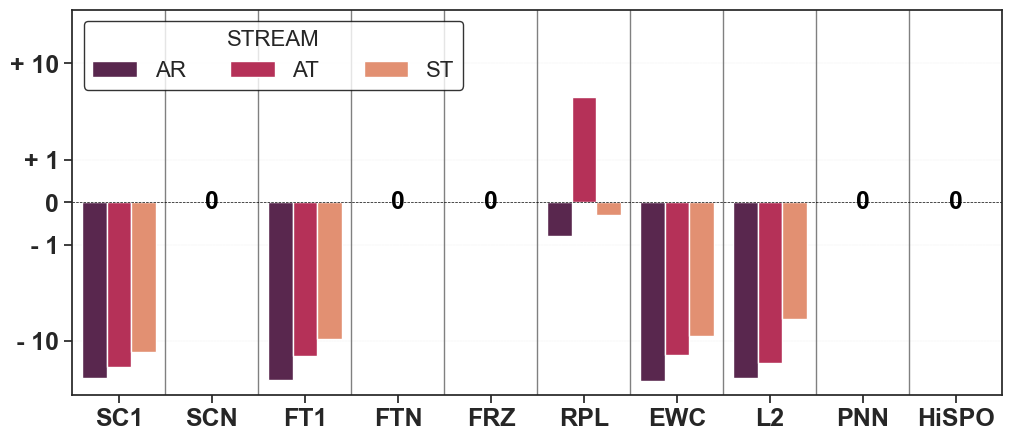

In [6]:
data_bwt = data[["STREAM", "METHOD", "BWT"]]

sns.set_theme(style="ticks")

plt.figure(figsize=(12, 5))

ax = sns.barplot(
    x="METHOD", 
    y="BWT", 
    hue="STREAM",
    data=data_bwt, 
    order=METHODS,
    width=0.8,
    palette="rocket",
)

# get x-tick positions (centers of the method groups)
xticks = ax.get_xticks()
for i in range(len(xticks)-1):
    # compute the midpoint between adjacent ticks
    x_sep = (xticks[i] + xticks[i+1]) / 2
    ax.axvline(x=x_sep, color='gray', linewidth=1.0, linestyle='-')

# list of methods to annotate with a central zero
methods_to_annotate = ["SCN", "FTN", "FRZ", "PNN", "HiSPO"]

for label, x in zip(ax.get_xticklabels(), ax.get_xticks()):
    if label.get_text() in methods_to_annotate:
        ax.text(x, 0, "0", ha='center', va='center', fontsize=18, fontweight='bold', color='black')

ax.set_xticklabels(ax.get_xticklabels(), horizontalalignment='center', fontsize=18, fontweight='bold')
ax.set_xlabel("")

ax.set_ylim(-50, 50)
ax.set_yscale("symlog")
ax.set_yticklabels(['- 10', '- 1', 0, '+ 1', '+ 10'], fontsize=18, fontweight='bold')
ax.set_ylabel("")

# plot lines at 0 (larger), -1 (smaller), 1 (smaller), 10 (smaller), -10 (smaller)
ax.axhline(-10, color='gray', linewidth=0.05, linestyle='-.', zorder=0)
ax.axhline(-1, color='gray', linewidth=0.05, linestyle='--', zorder=0)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.axhline(1, color='gray', linewidth=0.05, linestyle='--', zorder=0)
ax.axhline(10, color='gray', linewidth=0.05, linestyle='--', zorder=0)

# place legend in a row at top left, with box contoured by a black line
plt.legend(loc='upper left', bbox_to_anchor=(0.0, 1.0), fontsize=16, title="STREAM", ncol=3, title_fontsize=16, edgecolor='black')

# save as pdf
plt.savefig("./plots/bwt.pdf", bbox_inches='tight')

C:\Users\akobanda.UBISOFT-ORG\AppData\Local\Temp\ipykernel_29828\2482892511.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), horizontalalignment='center', fontsize=18, fontweight='bold')
C:\Users\akobanda.UBISOFT-ORG\AppData\Local\Temp\ipykernel_29828\2482892511.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['- 10', '- 1', 0, '+ 1', '+ 10'], fontsize=18, fontweight='bold')


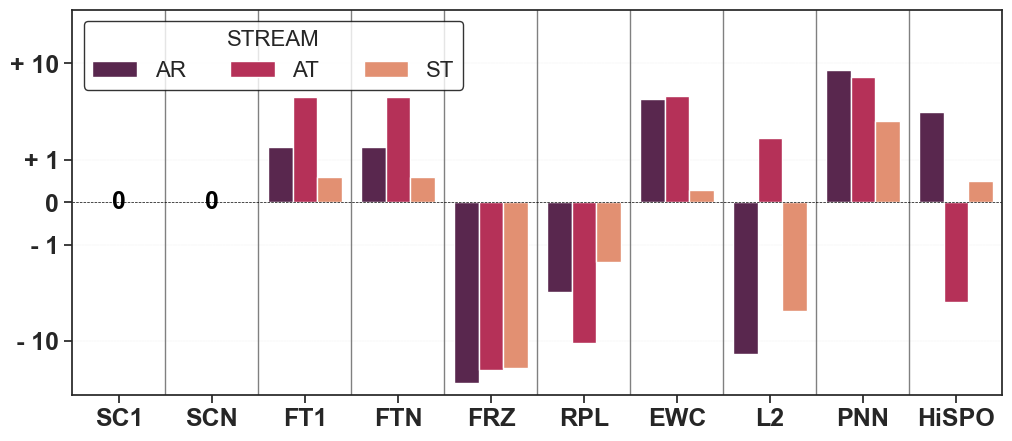

In [7]:
data_fwt = data[["STREAM", "METHOD", "FWT"]]

sns.set_theme(style="ticks")

plt.figure(figsize=(12, 5))

ax = sns.barplot(
    x="METHOD", 
    y="FWT", 
    hue="STREAM",
    data=data_fwt, 
    order=METHODS,
    width=0.8,
    palette="rocket"
)

# get x-tick positions (centers of the method groups)
xticks = ax.get_xticks()
for i in range(len(xticks)-1):
    # compute the midpoint between adjacent ticks
    x_sep = (xticks[i] + xticks[i+1]) / 2
    ax.axvline(x=x_sep, color='gray', linewidth=1.0, linestyle='-')

# list of methods to annotate with a central zero
methods_to_annotate = ["SC1", "SCN"]

for label, x in zip(ax.get_xticklabels(), ax.get_xticks()):
    if label.get_text() in methods_to_annotate:
        ax.text(x, 0, "0", ha='center', va='center', fontsize=18, fontweight='bold', color='black')
    
ax.set_xticklabels(ax.get_xticklabels(), horizontalalignment='center', fontsize=18, fontweight='bold')
ax.set_xlabel("")

ax.set_ylim(-50, 50)
ax.set_yscale("symlog")
ax.set_yticklabels(['- 10', '- 1', 0, '+ 1', '+ 10'], fontsize=18, fontweight='bold')
ax.set_ylabel("")

# plot lines at 0 (larger), -1 (smaller), 1 (smaller), 10 (smaller), -10 (smaller)
ax.axhline(-10, color='gray', linewidth=0.05, linestyle='-.', zorder=0)
ax.axhline(-1, color='gray', linewidth=0.05, linestyle='--', zorder=0)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.axhline(1, color='gray', linewidth=0.05, linestyle='--', zorder=0)
ax.axhline(10, color='gray', linewidth=0.05, linestyle='--', zorder=0)

# place legend in a row at top left
plt.legend(
    loc='upper left', 
    bbox_to_anchor=(0.0, 1.0), 
    fontsize=16, 
    title="STREAM", 
    ncol=3, 
    title_fontsize=16, 
    edgecolor='black',
)

# save as pdf
plt.savefig("./plots/fwt.pdf", bbox_inches='tight')

#### *2.B. Model Size - Inference*

In [8]:
# For SC1, FT1, FRZ, RPL, EWC, L2, SCN, FTN, PNN it is straightforward to compute the relative sizes

high_base, low_base = 0.6543, 0.6631

data_mem = {

    "METHOD": [

        "SC1 - FT1 - FRZ - RPL - EWC - L2",
        "SC1 - FT1 - FRZ - RPL - EWC - L2",
        "SC1 - FT1 - FRZ - RPL - EWC - L2",
        "SC1 - FT1 - FRZ - RPL - EWC - L2",

        "SCN - FTN",
        "SCN - FTN",
        "SCN - FTN",
        "SCN - FTN",

        "PNN", "PNN", "PNN", "PNN",
    
        # AR1
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",

        # AR2
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",

        # AT1
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",

        # AT2
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",

        # ST1
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",

        # ST2
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",

    ],

    "HIGH_MEM": [

        1.0, 1.0, 1.0, 1.0,

        1.0, 2.0, 3.0, 4.0,

        0.6543 / high_base, 2.2071 / high_base, 4.157 / high_base, 6.506 / high_base,

        # AR1
        1.0, 2.0, 3.0, 3.0,
        1.0, 2.0, 3.0, 3.0,
        1.0, 2.0, 3.0, 3.0,

        # AR2
        1.0, 2.0, 3.0, 4.0,
        1.0, 2.0, 3.0, 4.0,
        1.0, 2.0, 3.0, 4.0,

        # AT1
        1.0, 2.0, 2.0, 2.0,
        1.0, 2.0, 2.0, 2.0,
        1.0, 2.0, 2.0, 2.0,

        # AT2
        1.0, 1.0, 2.0, 3.0,
        1.0, 1.0, 2.0, 3.0,
        1.0, 2.0, 3.0, 4.0,

        # ST1
        1.0, 2.0, 2.0, 3.0,
        1.0, 2.0, 2.0, 3.0,
        1.0, 2.0, 2.0, 3.0,

        # ST2
        1.0, 2.0, 3.0, 3.0,
        1.0, 2.0, 3.0, 3.0,
        1.0, 2.0, 3.0, 3.0,

    ],

    "LOW_MEM": [

        1.0, 1.0, 1.0, 1.0,

        1.0, 2.0, 3.0, 4.0,

        0.6631 / low_base, 2.2234 / low_base, 4.212 / low_base, 6.596 / low_base,

        # AR1
        1.0, 2.0, 3.0, 3.0,
        1.0, 2.0, 3.0, 3.0,
        1.0, 2.0, 3.0, 3.0,

        # AR2
        1.0, 2.0, 3.0, 4.0,
        1.0, 2.0, 3.0, 4.0,
        1.0, 2.0, 3.0, 4.0,

        # AT1
        1.0, 2.0, 2.0, 2.0,
        1.0, 2.0, 2.0, 2.0,
        1.0, 2.0, 2.0, 3.0,

        # AT2
        1.0, 2.0, 3.0, 4.0,
        1.0, 2.0, 3.0, 4.0,
        1.0, 2.0, 3.0, 4.0,

        # ST1
        1.0, 2.0, 2.0, 3.0,
        1.0, 2.0, 2.0, 3.0,
        1.0, 2.0, 2.0, 3.0,

        # ST2
        1.0, 2.0, 3.0, 3.0,
        1.0, 2.0, 3.0, 3.0,
        1.0, 2.0, 3.0, 3.0,

    ],

    "TASK_IDX": [

        1, 2, 3, 4,

        1, 2, 3, 4,

        1, 2, 3, 4,

        # AR1
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,

        # AR2
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,

        # AT1
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,

        # AT2
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,

        # ST1
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,

        # ST2
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,

    ]

}

data_mem = pd.DataFrame(data_mem)

In [9]:
data_mem

,METHOD,HIGH_MEM,LOW_MEM,TASK_IDX
0,SC1 - FT1 - FRZ - RPL - EWC - L2,1.0,1.0,1
1,SC1 - FT1 - FRZ - RPL - EWC - L2,1.0,1.0,2
2,SC1 - FT1 - FRZ - RPL - EWC - L2,1.0,1.0,3
3,SC1 - FT1 - FRZ - RPL - EWC - L2,1.0,1.0,4
4,SCN - FTN,1.0,1.0,1
...,...,...,...,...
79,HiSPO,3.0,3.0,4
80,HiSPO,1.0,1.0,1
81,HiSPO,2.0,2.0,2
82,HiSPO,3.0,3.0,3


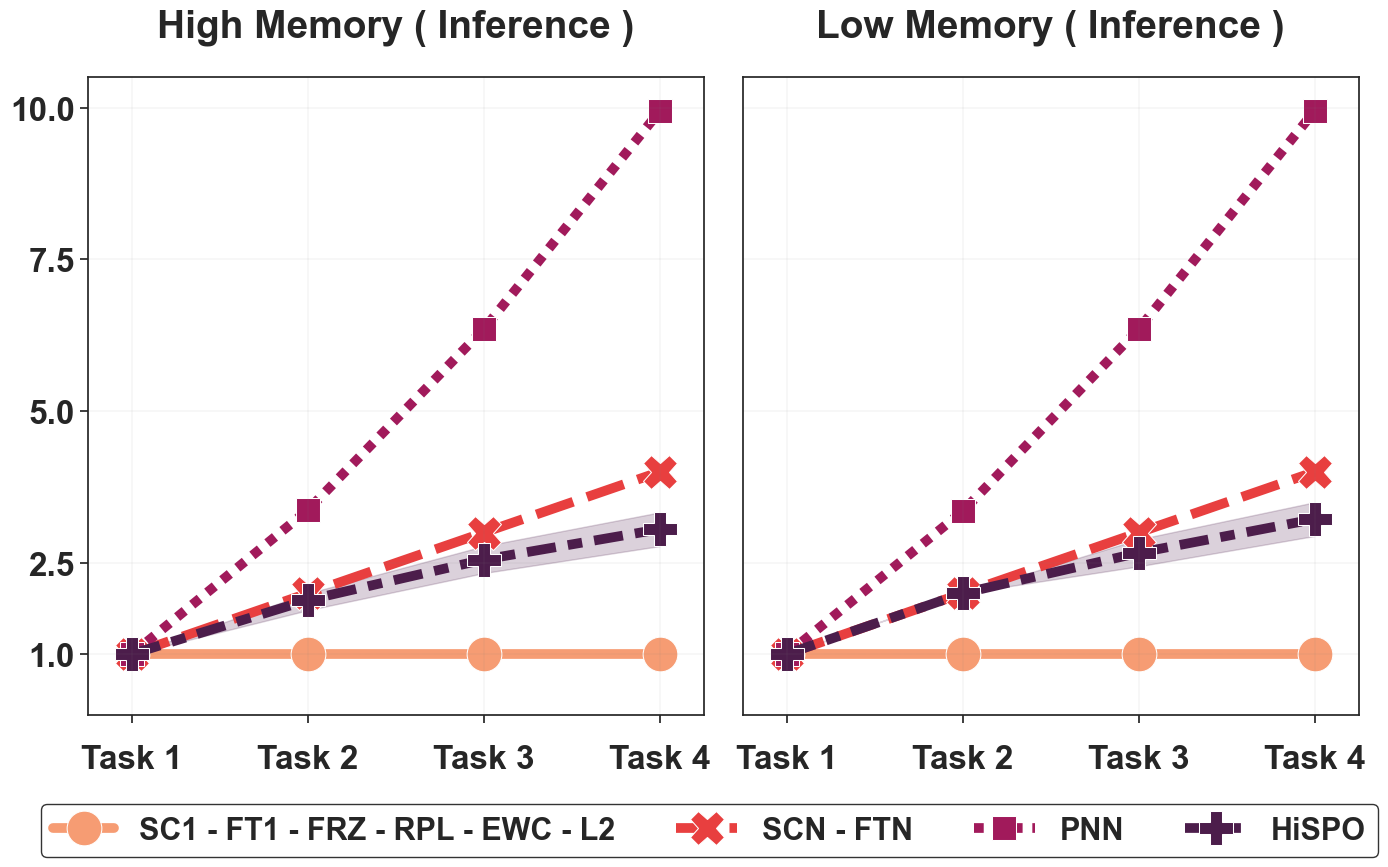

In [ ]:
sns.set_theme(style="ticks")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

###########################
# PLOT 1: Relative HIGH_MEM
###########################

if True:

    plot1 = sns.lineplot(
        data=data_mem,
        x="TASK_IDX",
        y="HIGH_MEM",
        hue="METHOD",
        style="METHOD",
        markers=True,
        markersize=25,
        linewidth=7.0,
        ax=ax1,
        palette="rocket_r",
        legend="full"
    )

    # remove the local legend from ax1
    ax1.legend_.remove()

    # configure ax1
    ax1.set_xlim(0.75, 4.25)
    ax1.set_xticks([1, 2, 3, 4])
    ax1.set_xticklabels(["Task 1", "Task 2", "Task 3", "Task 4"], fontsize=24, fontweight='bold', y=-0.025)
    ax1.set_xlabel("")
    for i in range(1, 5):
        ax1.axvline(i, color='gray', linewidth=0.125, linestyle='--')

    ax1.set_ylim(0.0, 10.5)
    ax1.set_yticks([1.0, 2.5, 5.0, 7.5, 10.0])
    ax1.set_yticklabels(["1.0", "2.5", "5.0", "7.5", "10.0"], fontsize=24, fontweight='bold')
    ax1.set_ylabel("")
    for yline in [1.0, 2.5, 5.0, 7.5, 10.0]:
        ax1.axhline(yline, color='gray', linewidth=0.125, linestyle='--')

    ax1.set_title("High Memory ( Inference )", fontsize=28, fontweight='bold', y=1.05)

    ##########################
    # PLOT 2: Relative LOW_MEM
    ##########################

    plot2 = sns.lineplot(
        data=data_mem,
        x="TASK_IDX",
        y="LOW_MEM",
        hue="METHOD",
        style="METHOD",
        markers=True,
        markersize=25,
        linewidth=7.0,
        ax=ax2,
        palette="rocket_r",
        legend="full"
    )

    # remove the local legend from ax2
    ax2.legend_.remove()

    # configure ax2
    ax2.set_xlim(0.75, 4.25)
    ax2.set_xticks([1, 2, 3, 4])
    ax2.set_xticklabels(["Task 1", "Task 2", "Task 3", "Task 4"], fontsize=24, fontweight='bold', y=-0.025)
    ax2.set_xlabel("")
    for i in range(1, 5):
        ax2.axvline(i, color='gray', linewidth=0.125, linestyle='--')
    ax2.set_ylim(0.0, 10.5)
    ax2.set_yticks([])
    ax2.set_ylabel("")
    for yline in [1.0, 2.5, 5.0, 7.5, 10.0]:
        ax2.axhline(yline, color='gray', linewidth=0.125, linestyle='--')

    ax2.set_title("Low Memory ( Inference )", fontsize=28, fontweight='bold', y=1.05)

    ########################
    # CREATE A SINGLE LEGEND
    ########################

    # collect handles and labels from one of the axes
    handles, labels = ax1.get_legend_handles_labels()

    # place a single legend in a row at the bottom
    fig.legend(
        handles, labels,
        loc='lower center',
        bbox_to_anchor=(0.5125, -0.1),
        ncol=4,
        fontsize=22,
        title="",
        title_fontsize=20,
        edgecolor='black',
        prop={'weight': 'bold', 'size': 22}
    )

    # SAVE

    plt.tight_layout(w_pad=0.5, h_pad=5.0)
    plt.savefig("./plots/mem.pdf", bbox_inches='tight')
    plt.show()


#### *2.C. Model Size - Training*

In [12]:
# For SC1, FT1, FRZ, RPL, EWC, L2, SCN, FTN, PNN it is straightforward to compute the relative sizes

high_base, low_base = 0.6543, 0.6631

data_mem_training = {

    "METHOD": [

        "SC1 - FT1 - FRZ - RPL",
        "SC1 - FT1 - FRZ - RPL",
        "SC1 - FT1 - FRZ - RPL",
        "SC1 - FT1 - FRZ - RPL",

        "EWC", "EWC", "EWC", "EWC",

        "L2", "L2", "L2", "L2",

        "SCN - FTN",
        "SCN - FTN",
        "SCN - FTN",
        "SCN - FTN",

        "PNN", "PNN", "PNN", "PNN",
    
        # AR1
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",

        # AR2
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",

        # AT1
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",

        # AT2
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",

        # ST1
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",

        # ST2
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",
        "HiSPO", "HiSPO", "HiSPO", "HiSPO",

    ],

    "HIGH_MEM": [

        1.0, 1.0, 1.0, 1.0,

        1.0, 2.0, 3.0, 4.0,

        1.963 / high_base, 3.272 / high_base, 4.58 / high_base, 5.889 / high_base,

        1.309 / high_base, 1.963 / high_base, 2.617 / high_base, 3.272 / high_base,

        0.6543 / high_base, 2.2071 / high_base, 4.157 / high_base, 6.506 / high_base,

        # AR1
        1.0, 2.0, 3.0, 3.0,
        1.0, 2.0, 3.0, 3.0,
        1.0, 2.0, 3.0, 3.0,

        # AR2
        1.0, 2.0, 3.0, 4.0,
        1.0, 2.0, 3.0, 4.0,
        1.0, 2.0, 3.0, 4.0,

        # AT1
        1.0, 2.0, 2.0, 2.0,
        1.0, 2.0, 2.0, 2.0,
        1.0, 2.0, 2.0, 2.0,

        # AT2
        1.0, 1.0, 2.0, 3.0,
        1.0, 1.0, 2.0, 3.0,
        1.0, 2.0, 3.0, 4.0,

        # ST1
        1.0, 2.0, 2.0, 3.0,
        1.0, 2.0, 2.0, 3.0,
        1.0, 2.0, 2.0, 3.0,

        # ST2
        1.0, 2.0, 3.0, 3.0,
        1.0, 2.0, 3.0, 3.0,
        1.0, 2.0, 3.0, 3.0,

    ],

    "LOW_MEM": [

        1.0, 1.0, 1.0, 1.0,

        1.0, 2.0, 3.0, 4.0,

        1.989 / low_base, 3.316 / low_base, 4.642 / low_base, 5.968 / low_base,

        1.326 / low_base, 1.989 / low_base, 2.653 / low_base, 3.316 / low_base,

        0.6631 / low_base, 2.2234 / low_base, 4.212 / low_base, 6.596 / low_base,

        # AR1
        1.0, 2.0, 3.0, 3.0,
        1.0, 2.0, 3.0, 3.0,
        1.0, 2.0, 3.0, 3.0,

        # AR2
        1.0, 2.0, 3.0, 4.0,
        1.0, 2.0, 3.0, 4.0,
        1.0, 2.0, 3.0, 4.0,

        # AT1
        1.0, 2.0, 2.0, 2.0,
        1.0, 2.0, 2.0, 2.0,
        1.0, 2.0, 2.0, 3.0,

        # AT2
        1.0, 2.0, 3.0, 4.0,
        1.0, 2.0, 3.0, 4.0,
        1.0, 2.0, 3.0, 4.0,

        # ST1
        1.0, 2.0, 2.0, 3.0,
        1.0, 2.0, 2.0, 3.0,
        1.0, 2.0, 2.0, 3.0,

        # ST2
        1.0, 2.0, 3.0, 3.0,
        1.0, 2.0, 3.0, 3.0,
        1.0, 2.0, 3.0, 3.0,

    ],

    "TASK_IDX": [

        1, 2, 3, 4,

        1, 2, 3, 4,

        1, 2, 3, 4,

        1, 2, 3, 4,
        
        1, 2, 3, 4,

        # AR1
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,

        # AR2
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,

        # AT1
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,

        # AT2
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,

        # ST1
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,

        # ST2
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,

    ]

}

data_mem_training = pd.DataFrame(data_mem_training)

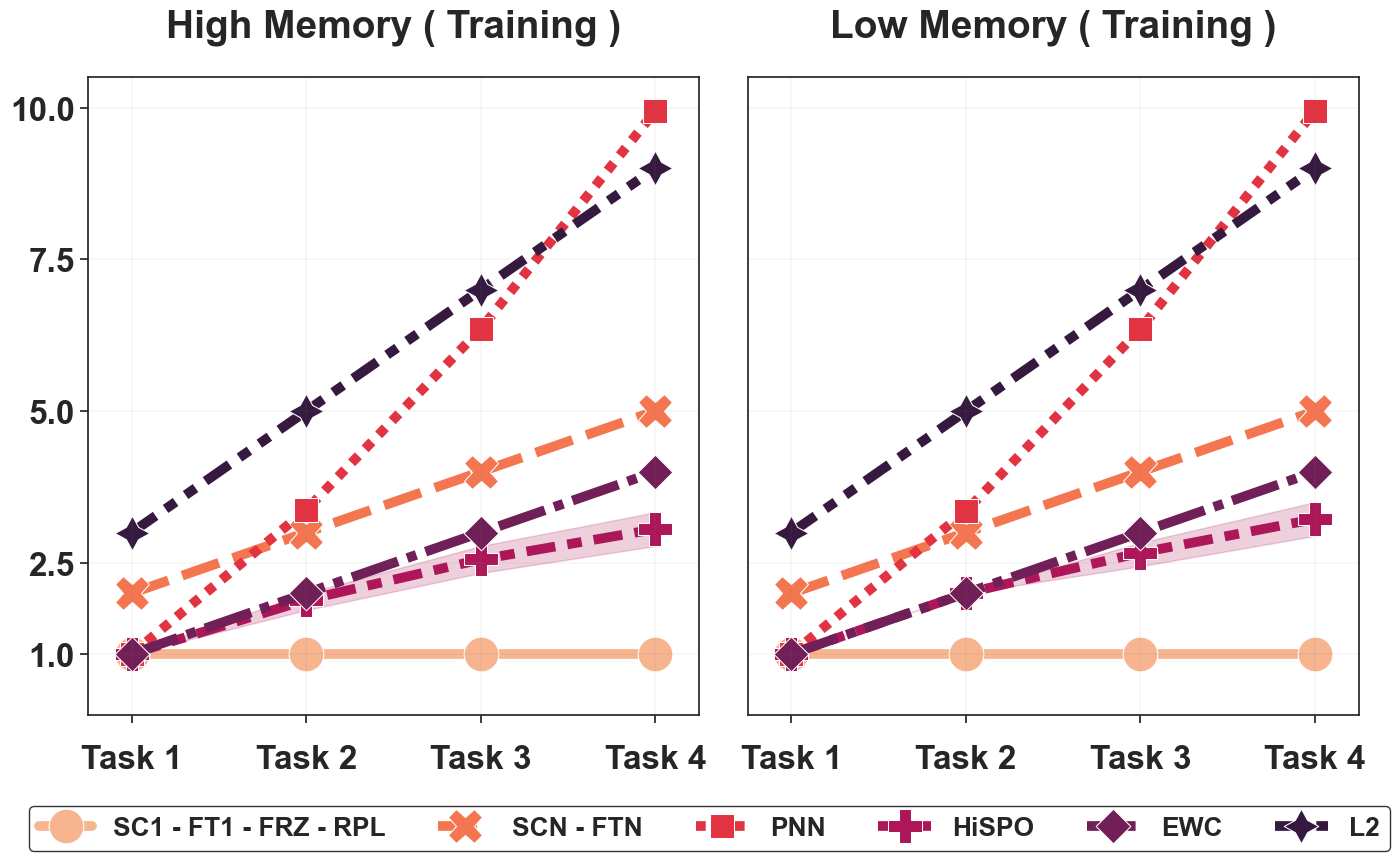

In [ ]:
sns.set_theme(style="ticks")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

METHOD_ORDER = ["SC1 - FT1 - FRZ - RPL", "SCN - FTN", "PNN", "HiSPO", "EWC", "L2"]
my_palette = sns.color_palette("rocket_r", n_colors=len(METHOD_ORDER))

###########################
# PLOT 1: Relative HIGH_MEM
###########################

if True:

    plot1 = sns.lineplot(
        data=data_mem_training,
        x="TASK_IDX",
        y="HIGH_MEM",
        hue="METHOD",
        style="METHOD",
        markers=True,
        markersize=25,
        linewidth=7.0,
        ax=ax1,
        hue_order=METHOD_ORDER,
        style_order=METHOD_ORDER,
        palette=my_palette,
        legend="full"
    )

    # remove the local legend from ax1
    ax1.legend_.remove()

    # configure ax1
    ax1.set_xlim(0.75, 4.25)
    ax1.set_xticks([1, 2, 3, 4])
    ax1.set_xticklabels(["Task 1", "Task 2", "Task 3", "Task 4"], fontsize=24, fontweight='bold', y=-0.025)
    ax1.set_xlabel("")
    for i in range(1, 5):
        ax1.axvline(i, color='gray', linewidth=0.125, linestyle='--')

    ax1.set_ylim(0.0, 10.5)
    ax1.set_yticks([1.0, 2.5, 5.0, 7.5, 10.0])
    ax1.set_yticklabels(["1.0", "2.5", "5.0", "7.5", "10.0"], fontsize=24, fontweight='bold')
    ax1.set_ylabel("")
    for yline in [1.0, 2.5, 5.0, 7.5, 10.0]:
        ax1.axhline(yline, color='gray', linewidth=0.125, linestyle='--')

    ax1.set_title("High Memory ( Training )", fontsize=28, fontweight='bold', y=1.05)

    ##########################
    # PLOT 2: Relative LOW_MEM
    ##########################

    plot2 = sns.lineplot(
        data=data_mem_training,
        x="TASK_IDX",
        y="LOW_MEM",
        hue="METHOD",
        style="METHOD",
        markers=True,
        markersize=25,
        linewidth=7.0,
        ax=ax2,
        hue_order=METHOD_ORDER,
        style_order=METHOD_ORDER,
        palette=my_palette,
        legend="full"
    )

    # remove the local legend from ax2
    ax2.legend_.remove()

    # configure ax2
    ax2.set_xlim(0.75, 4.25)
    ax2.set_xticks([1, 2, 3, 4])
    ax2.set_xticklabels(["Task 1", "Task 2", "Task 3", "Task 4"], fontsize=24, fontweight='bold', y=-0.025)
    ax2.set_xlabel("")
    for i in range(1, 5):
        ax2.axvline(i, color='gray', linewidth=0.125, linestyle='--')
    ax2.set_ylim(0.0, 10.5)
    ax2.set_yticks([])
    ax2.set_ylabel("")
    for yline in [1.0, 2.5, 5.0, 7.5, 10.0]:
        ax2.axhline(yline, color='gray', linewidth=0.125, linestyle='--')

    ax2.set_title("Low Memory ( Training )", fontsize=28, fontweight='bold', y=1.05)

    ########################
    # CREATE A SINGLE LEGEND
    ########################

    # collect handles and labels from one of the axes
    handles, labels = ax1.get_legend_handles_labels()

    # place a single legend in a row at the bottom
    fig.legend(
        handles, labels,
        loc='lower center',
        bbox_to_anchor=(0.5125, -0.09),
        ncol=6,
        fontsize=20,
        title="",
        title_fontsize=20,
        edgecolor='black',
        prop={'weight': 'bold', 'size': 19}
    )

    # SAVE

    plt.tight_layout()
    plt.savefig("./plots/mem_all.pdf", bbox_inches='tight')
    plt.show()

#### *2.D. Training Duration*

In [33]:
# reported from avalaible logs

data_time_training = {

    "METHODS": [
        
        "SC1", "SCN", "FT1", "FTN", 
        "FRZ", 
        "RPL", 
        "EWC", 
        "L2", 
        "PNN", 
        "HiSPO",
    
    ],

    "TIME": [

        23 * 4, 23 * 4, 23 * 4, 23 * 4, 
        23,
        25 * 4,
        25 + 37 + 49 + 57,
        25 + 30 + 37 + 45,
        25 + 40 + 44 + 50,
        27 + 50 + 80 + 85

    ]

}

data_time_training = pd.DataFrame(data_time_training)

C:\Users\akobanda.UBISOFT-ORG\AppData\Local\Temp\ipykernel_29828\1221969257.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\akobanda.UBISOFT-ORG\AppData\Local\Temp\ipykernel_29828\1221969257.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), horizontalalignment='center', fontsize=18, fontweight='bold', y=-0.025)


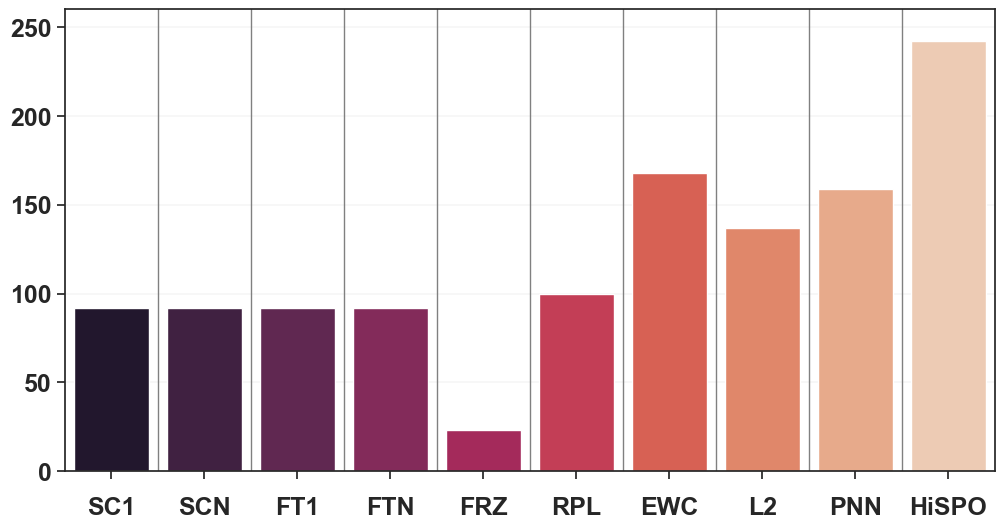

In [45]:
# plot histogram
# x -> methods
# y -> time

sns.set_theme(style="ticks")

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x="METHODS", 
    y="TIME", 
    data=data_time_training, 
    palette="rocket",
    order=METHODS,
    linewidth=1.0
)

# get x-tick positions (centers of the method groups)
xticks = ax.get_xticks()
for i in range(len(xticks)-1):
    # compute the midpoint between adjacent ticks
    x_sep = (xticks[i] + xticks[i+1]) / 2
    ax.axvline(x=x_sep, color='gray', linewidth=1.0, linestyle='-')

# list of methods to annotate with a central zero
methods_to_annotate = ["SC1", "SCN", "FT1", "FTN", "FRZ", "RPL", "EWC", "L2", "PNN", "HiSPO"]

ax.set_xticklabels(ax.get_xticklabels(), horizontalalignment='center', fontsize=18, fontweight='bold', y=-0.025)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_ylim(0, 260)
ax.set_yticks([0, 50, 100, 150, 200, 250])
ax.set_yticklabels(["0", "50", "100", "150", "200", "250"], fontsize=18, fontweight='bold')

# grid lines (behind bars)
for yline in [50, 100, 150, 200, 250]:
    ax.axhline(yline, color='gray', linewidth=0.125, linestyle='--', zorder=0)

# save as pdf
plt.savefig("./plots/training_time.pdf", bbox_inches='tight')
plt.show()

___
___